In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic = df.copy()
titanic.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
682,683,0,3,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.2250,NaN,S
576,577,1,2,"Garside, Miss. Ethel",female,34.0,0,0,243880,13.0000,NaN,S
424,425,0,3,"Rosblom, Mr. Viktor Richard",male,18.0,1,1,370129,20.2125,NaN,S
298,299,1,1,"Saalfeld, Mr. Adolphe",male,NaN,0,0,19988,30.5000,C106,S
825,826,0,3,"Flynn, Mr. John",male,NaN,0,0,368323,6.9500,NaN,Q


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 📘 Data Description – Titanic Dataset

The Titanic dataset contains information about passengers aboard the RMS Titanic, which sank on April 15, 1912.  
This dataset is commonly used for classification tasks where the objective is to predict whether a passenger survived or not.

The dataset is widely available on the Kaggle platform for machine learning practice.

---

## 🎯 Objective

The goal of this dataset is to predict passenger survival.

- **Survived = 0** → Passenger did not survive  
- **Survived = 1** → Passenger survived  

---

## 📊 Dataset Overview

- Total observations (rows): **891**
- Total features (columns): **12**
- Target variable: **Survived**

---

## 🗂 Feature Description

| Column Name  | Description |
|-------------|------------|
| PassengerId | Unique identifier for each passenger |
| Survived    | Survival status (0 = No, 1 = Yes) |
| Pclass      | Passenger class (1 = First, 2 = Second, 3 = Third) |
| Name        | Name of the passenger |
| Sex         | Gender of the passenger |
| Age         | Age in years |
| SibSp       | Number of siblings/spouses aboard |
| Parch       | Number of parents/children aboard |
| Ticket      | Ticket number |
| Fare        | Ticket fare paid |
| Cabin       | Cabin number (contains many missing values) |
| Embarked    | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

---

## 🔎 Data Characteristics

- The dataset contains both **numerical** and **categorical** features.
- Age, Cabin and Embarked columns have 177, 687 and 2 values.

In [ ]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##Problems with the dataset:
- Missing values in `Age`, `Cabin` and `Embarked` columns.[177,687,2] (Completeness)
- `Survived`, `Pclass`, `Sex` and `Embarked` columns dtype should be categorical.(Accuracy).

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Checking `Sex` column for inconsistency:**

In [ ]:
titanic["Sex"].unique()

array(['male', 'female'], dtype=object)

- No in consistency problem in `Sex` column.

**Checking `Age` column for validity and accuracy:**

In [ ]:
titanic[titanic["Age"] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [ ]:
titanic[titanic["Age"] > 100]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [ ]:
titanic["Age"].dtype

dtype('float64')

- No in validity problem in `Age` column.
- Datatype should be int not float it could be due to missing values.

**Checking `Sibp` and `Parch` column for validity and accuracy:**

In [ ]:
titanic["SibSp"].unique()

array([1, 0, 3, 4, 2, 5, 8])

In [ ]:
titanic["Parch"].unique()

array([0, 1, 2, 5, 3, 4, 6])

- No problem in these two columns so far.

**Checking `Fare` column for validity and accuracy:**

In [ ]:
titanic[titanic["Fare"] < 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


- No problem so far in this column.

**Checking `Embarked` column for consistency:**

In [ ]:
titanic["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

- No problem with this column, nan is due to missing values.

**Solving the missing values issue:**
- There are too many missng values in `Cabin` column, so we are going to remove it and it does not add much meaning to dataset.
- We are going to replace missing values in `Age` column with mean.
- Removing 2 rows where the `Embarked` column has NAN.

In [ ]:
titanic.drop(columns=["Cabin"], inplace=True)
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
73,74,0,3,"Chronopoulos, Mr. Apostolos",male,26.0,1,0,2680,14.4542,C
524,525,0,3,"Kassem, Mr. Fared",male,NaN,0,0,2700,7.2292,C
605,606,0,3,"Lindell, Mr. Edvard Bengtsson",male,36.0,1,0,349910,15.5500,S
566,567,0,3,"Stoytcheff, Mr. Ilia",male,19.0,0,0,349205,7.8958,S


In [ ]:
titanic.dropna(subset=["Embarked"], inplace=True)
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
194,195,1,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44.0,0,0,PC 17610,27.7208,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,S
566,567,0,3,"Stoytcheff, Mr. Ilia",male,19.0,0,0,349205,7.8958,S
728,729,0,2,"Bryhl, Mr. Kurt Arnold Gottfrid",male,25.0,1,0,236853,26.0000,S


In [ ]:
print("Original dimension of the dataset:",df.shape)
print("Dimension of the dataset after droping Cabin columns and 2 rows where embarked was NAN:",titanic.shape)

Original dimension of the dataset: (891, 12)
Dimension of the dataset after droping Cabin columns and 2 rows where embarked was NAN: (889, 11)


In [ ]:
# now filling values in age column
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].mean()).astype("int32")
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
557,558,0,1,"Robbins, Mr. Victor",male,29,0,0,PC 17757,227.5250,C
451,452,0,3,"Hagland, Mr. Ingvald Olai Olsen",male,29,1,0,65303,19.9667,S
643,644,1,3,"Foo, Mr. Choong",male,29,0,0,1601,56.4958,S
665,666,0,2,"Hickman, Mr. Lewis",male,32,2,0,S.O.C. 14879,73.5000,S


In [ ]:
print(f"Corrected data type of the Age column from {df["Age"].dtype} to {titanic["Age"].dtype}")

Corrected data type of the Age column from float64 to int32


In [ ]:
print("Col    Before     After")
print(f"Age        {df["Age"].isna().sum()}    {titanic["Age"].isna().sum()}")
print(f"Embarked   {df["Embarked"].isna().sum()}      {titanic["Embarked"].isna().sum()}")

Col    Before     After
Age        177    0
Embarked   2      0


- So, now all the missing values have been dealt with. No more missing values in the dataset.

In [ ]:
cols = ["Survived","Pclass","Sex","Embarked"]

for col in cols:
  titanic[col] = titanic[col].astype("category")

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  889 non-null    int64   
 1   Survived     889 non-null    category
 2   Pclass       889 non-null    category
 3   Name         889 non-null    object  
 4   Sex          889 non-null    category
 5   Age          889 non-null    int32   
 6   SibSp        889 non-null    int64   
 7   Parch        889 non-null    int64   
 8   Ticket       889 non-null    object  
 9   Fare         889 non-null    float64 
 10  Embarked     889 non-null    category
dtypes: category(4), float64(1), int32(1), int64(3), object(2)
memory usage: 56.1+ KB


- Now the data types are right.

## Handling Duplicates

In [ ]:
titanic.duplicated().sum()

np.int64(0)

In [ ]:
titanic.duplicated(subset=["Name"]).sum()

np.int64(0)

In [ ]:
titanic.duplicated(subset=["PassengerId"]).sum()

np.int64(0)

- There is no duplicates in the dataset.

## Univariate Analysis


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  889 non-null    int64   
 1   Survived     889 non-null    category
 2   Pclass       889 non-null    category
 3   Name         889 non-null    object  
 4   Sex          889 non-null    category
 5   Age          889 non-null    int32   
 6   SibSp        889 non-null    int64   
 7   Parch        889 non-null    int64   
 8   Ticket       889 non-null    object  
 9   Fare         889 non-null    float64 
 10  Embarked     889 non-null    category
dtypes: category(4), float64(1), int32(1), int64(3), object(2)
memory usage: 56.1+ KB


### Categorical Columns
#### Survived:
- Less people survived (38.2%)


In [ ]:
print(titanic["Survived"].value_counts())
print(titanic["Survived"].value_counts(normalize=True)*100)

Survived
0    549
1    340
Name: count, dtype: int64
Survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


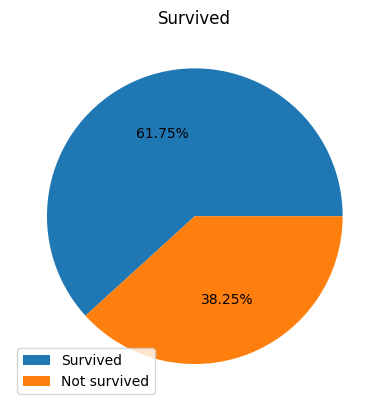

In [ ]:
plt.pie(titanic["Survived"].value_counts(),autopct="%.2f%%")
plt.legend(["Survived","Not survived"])
plt.title("Survived")
plt.show()

#### Pclass
- More people were in passenger class 3 (55.2%).
- In class 2, there were 20.7% people and in class 1, 24.1% people.

In [ ]:
print(titanic["Pclass"].value_counts())
print(titanic["Pclass"].value_counts(normalize=True)*100)

Pclass
3    491
1    214
2    184
Name: count, dtype: int64
Pclass
3    55.230596
1    24.071991
2    20.697413
Name: proportion, dtype: float64


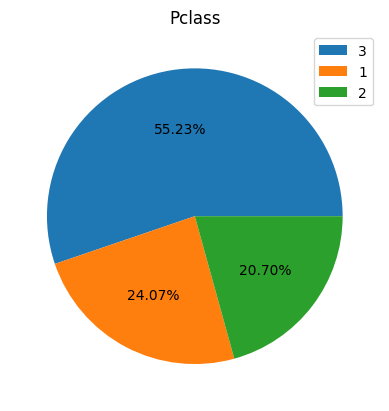

In [ ]:
plt.pie(titanic["Pclass"].value_counts(),autopct="%.2f%%")
plt.legend([3,1,2])
plt.title("Pclass")
plt.show()

#### Sex:
- There were more male than female.

In [ ]:
print(titanic["Sex"].value_counts())
print(titanic["Sex"].value_counts(normalize=True)*100)

Sex
male      577
female    312
Name: count, dtype: int64
Sex
male      64.904387
female    35.095613
Name: proportion, dtype: float64


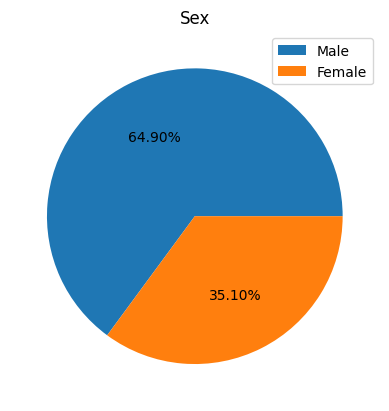

In [ ]:
plt.pie(titanic["Sex"].value_counts(),autopct="%.2f%%")
plt.legend(["Male","Female"])
plt.title("Sex")
plt.show()

#### Embarked
- There were a lot of people from Southampton than others.
- There were more people from Cherbourg than Queenstown.

In [ ]:
print(titanic["Embarked"].value_counts())
print(titanic["Embarked"].value_counts(normalize=True)*100)

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64


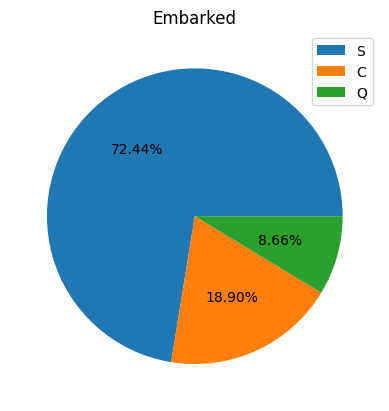

In [ ]:
plt.pie(titanic["Embarked"].value_counts(),autopct="%.2f%%")
plt.legend(["S","C","Q"])
plt.title("Embarked")
plt.show()

In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  889 non-null    int64   
 1   Survived     889 non-null    category
 2   Pclass       889 non-null    category
 3   Name         889 non-null    object  
 4   Sex          889 non-null    category
 5   Age          889 non-null    int32   
 6   SibSp        889 non-null    int64   
 7   Parch        889 non-null    int64   
 8   Ticket       889 non-null    object  
 9   Fare         889 non-null    float64 
 10  Embarked     889 non-null    category
dtypes: category(4), float64(1), int32(1), int64(3), object(2)
memory usage: 56.1+ KB


### Numerical Columns
#### Age:
- There are a lot of outliers.(65)
- It looks like a right-skewed distribution.

In [ ]:
titanic["Age"].describe()

,Age
count,889.000000
mean,29.498313
std,12.979638
min,0.000000
25%,22.000000
50%,29.000000
75%,35.000000
max,80.000000


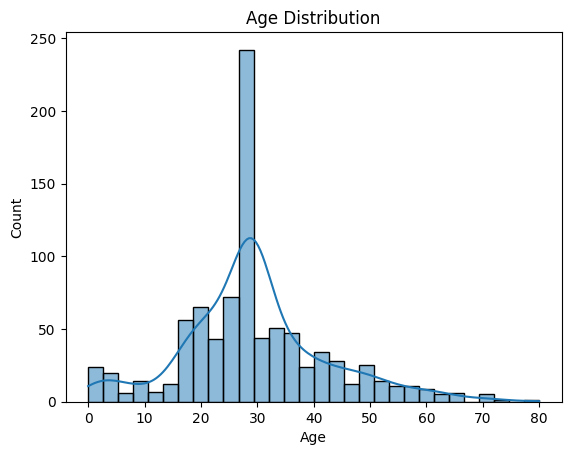

In [ ]:
sns.histplot(data=titanic,x="Age",kde=True)
plt.title("Age Distribution")
plt.show()

<Axes: ylabel='Age'>

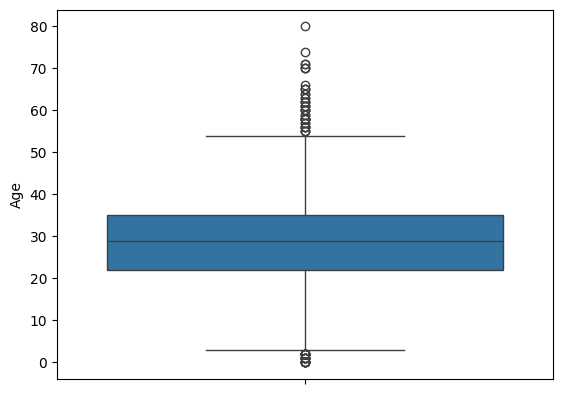

In [ ]:
sns.boxplot(data=titanic,y="Age")

In [ ]:
q1 = 22.000000
q3 = 35.000000
iqr = q3-q1
mini = q1 - 1.5*iqr
maxi = q3 + 1.5*iqr
titanic[titanic["Age"]>maxi]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.5500,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55,0,0,248706,16.0000,S
33,34,0,2,"Wheadon, Mr. Edward H",male,66,0,0,C.A. 24579,10.5000,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65,0,1,113509,61.9792,C
94,95,0,3,"Coxon, Mr. Daniel",male,59,0,0,364500,7.2500,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71,0,0,PC 17754,34.6542,C
116,117,0,3,"Connors, Mr. Patrick",male,70,0,0,370369,7.7500,Q
152,153,0,3,"Meo, Mr. Alfonzo",male,55,0,0,A.5. 11206,8.0500,S
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61,0,0,111240,33.5000,S
174,175,0,1,"Smith, Mr. James Clinch",male,56,0,0,17764,30.6958,C


In [ ]:
print("Highest point in the dataset excluding outliers :",maxi)
print("Lowest point in the dataset excluding outliers :",mini)
print("Number of outliers after highest point: ",titanic[titanic["Age"]>maxi].shape[0])
print("Number of outliers after lowest point: ",titanic[titanic["Age"]<mini].shape[0])

Highest point in the dataset excluding outliers : 54.5
Lowest point in the dataset excluding outliers : 2.5
Number of outliers after highest point:  41
Number of outliers after lowest point:  24


#### Fare
- highly positively skewed distribution.
- a lot of outliers, maybe becuase fare is combined.(114)

In [ ]:
titanic["Fare"].describe()

,Fare
count,889.000000
mean,32.096681
std,49.697504
min,0.000000
25%,7.895800
50%,14.454200
75%,31.000000
max,512.329200


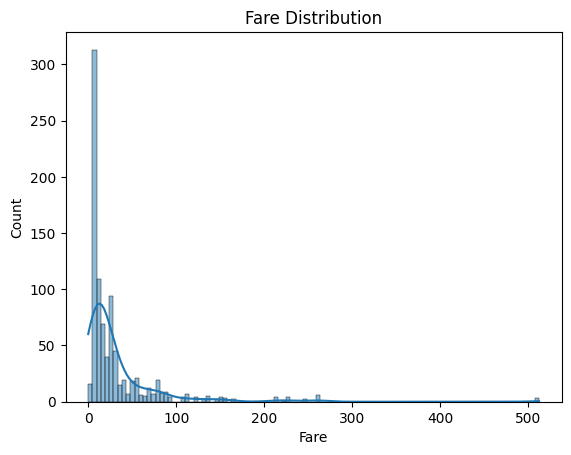

In [ ]:
sns.histplot(data=titanic,x="Fare",kde=True)
plt.title("Fare Distribution")
plt.show()

<Axes: ylabel='Fare'>

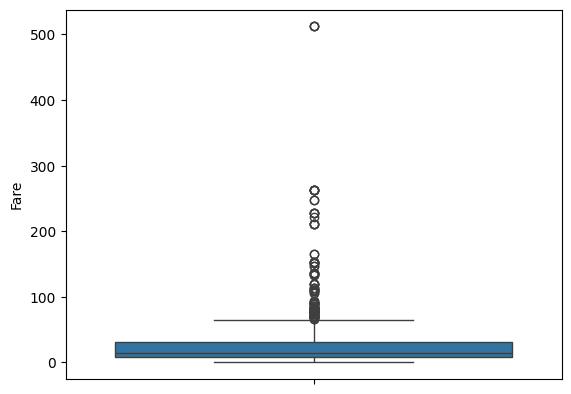

In [ ]:
sns.boxplot(data=titanic,y="Fare")

In [ ]:
q1 = 7.895800
q3 = 31.000000
iqr = q3-q1
mini = q1 - 1.5*iqr
maxi = q3 + 1.5*iqr
titanic[titanic["Fare"]>maxi]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29,1,0,PC 17569,146.5208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28,1,0,PC 17604,82.1708,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49,1,0,PC 17572,76.7292,C
...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,29,8,2,CA. 2343,69.5500,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,29,1,0,17453,89.1042,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45,1,1,36928,164.8667,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29,8,2,CA. 2343,69.5500,S


In [ ]:
print("Highest point in the dataset excluding outliers :",maxi)
print("Lowest point in the dataset excluding outliers :",mini)
print("Number of outliers after highest point: ",titanic[titanic["Fare"]>maxi].shape[0])
print("Number of outliers after lowest point: ",titanic[titanic["Fare"]<mini].shape[0])

Highest point in the dataset excluding outliers : 65.6563
Lowest point in the dataset excluding outliers : -26.7605
Number of outliers after highest point:  114
Number of outliers after lowest point:  0


### Feature Engineering

**Making a new family size column for better understanding.**

In [ ]:
titanic["Family_size"] = titanic["SibSp"] + titanic["Parch"] + 1

In [ ]:
titanic.sample(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size
158,159,0,3,"Smiljanic, Mr. Mile",male,29,0,0,315037,8.6625,S,1
747,748,1,2,"Sinkkonen, Miss. Anna",female,30,0,0,250648,13.0000,S,1
452,453,0,1,"Foreman, Mr. Benjamin Laventall",male,30,0,0,113051,27.7500,C,1
596,597,1,2,"Leitch, Miss. Jessie Wills",female,29,0,0,248727,33.0000,S,1
270,271,0,1,"Cairns, Mr. Alexander",male,29,0,0,113798,31.0000,S,1
862,863,1,1,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",female,48,0,0,17466,25.9292,S,1
703,704,0,3,"Gallagher, Mr. Martin",male,25,0,0,36864,7.7417,Q,1


In [ ]:
titanic[titanic["Family_size"] != 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,2
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.0750,S,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,S,3
...,...,...,...,...,...,...,...,...,...,...,...,...
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28,1,0,P/PP 3381,24.0000,C,2
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56,0,1,11767,83.1583,C,2
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25,0,1,230433,26.0000,S,2
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39,0,5,382652,29.1250,Q,6


In [ ]:
titanic.drop(["SibSp","Parch"],axis=1,inplace=True)

In [ ]:
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size
521,522,0,3,"Vovk, Mr. Janko",male,22,349252,7.8958,S,1
113,114,0,3,"Jussila, Miss. Katriina",female,20,4136,9.8250,S,2
150,151,0,2,"Bateman, Rev. Robert James",male,51,S.O.P. 1166,12.5250,S,1


**Making another column `alone` that will tell us if the person is alone or not**

In [ ]:
titanic["Is_alone"] = (titanic["Family_size"] == 1).astype("category")

In [ ]:
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,Is_alone
554,555,1,3,"Ohman, Miss. Velin",female,22,347085,7.775,S,1,1
389,390,1,2,"Lehmann, Miss. Bertha",female,17,SC 1748,12.000,C,1,1
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39,112050,0.000,S,1,1
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18,392091,9.350,S,2,0


**Here, the fare is collective we can divide the fare by ticket count as many people are traveling using same ticket.**

In [ ]:
titanic["Ticket_count"] = titanic.groupby("Ticket")["Ticket"].transform("count")
titanic["Individual_fare"] = titanic["Fare"] / titanic["Ticket_count"]
titanic.sample(6)


,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,Is_alone,Ticket_count,Individual_fare
330,331,1,3,"McCoy, Miss. Agnes",female,29,367226,23.2500,Q,3,0,2,11.6250
681,682,1,1,"Hassab, Mr. Hammad",male,27,PC 17572,76.7292,C,1,1,3,25.5764
93,94,0,3,"Dean, Mr. Bertram Frank",male,26,C.A. 2315,20.5750,S,4,0,2,10.2875
871,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47,11751,52.5542,S,3,0,2,26.2771
384,385,0,3,"Plotcharsky, Mr. Vasil",male,29,349227,7.8958,S,1,1,1,7.8958
101,102,0,3,"Petroff, Mr. Pastcho (""Pentcho"")",male,29,349215,7.8958,S,1,1,1,7.8958


In [ ]:
titanic.drop(["Fare"],axis=1,inplace=True)
titanic.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Embarked,Family_size,Is_alone,Ticket_count,Individual_fare
324,325,0,3,"Sage, Mr. George John Jr",male,29,CA. 2343,S,11,0,7,9.935714
95,96,0,3,"Shorney, Mr. Charles Joseph",male,29,374910,S,1,1,1,8.050000
814,815,0,3,"Tomlin, Mr. Ernest Portage",male,30,364499,S,1,1,1,8.050000


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      889 non-null    int64   
 1   Survived         889 non-null    category
 2   Pclass           889 non-null    category
 3   Name             889 non-null    object  
 4   Sex              889 non-null    category
 5   Age              889 non-null    int32   
 6   Ticket           889 non-null    object  
 7   Embarked         889 non-null    category
 8   Family_size      889 non-null    int64   
 9   Is_alone         889 non-null    int16   
 10  Ticket_count     889 non-null    int64   
 11  Individual_fare  889 non-null    float64 
dtypes: category(4), float64(1), int16(1), int32(1), int64(3), object(2)
memory usage: 57.8+ KB


### Bivariate Analysis
**Target: Survived**
#### Survived vs Pclass:
- More people from class 1 survived than 2 and 3.
- Survival rate: class 1 > class 2 > class 3.

In [ ]:
pd.crosstab(titanic["Pclass"],titanic["Survived"])

Survived,0,1
Pclass,,
1,80,134
2,97,87
3,372,119


In [ ]:
cross = pd.crosstab(titanic["Pclass"],titanic["Survived"],normalize="index")*100
cross

Survived,0,1
Pclass,,
1,37.383178,62.616822
2,52.717391,47.282609
3,75.763747,24.236253


<Axes: xlabel='Survived', ylabel='Pclass'>

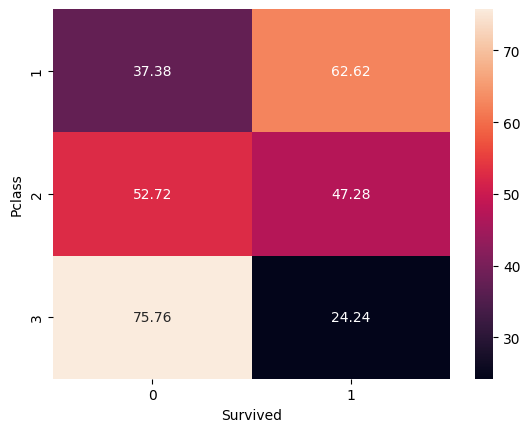

In [ ]:
sns.heatmap(cross,annot=True, fmt='.2f')

#### Survived vs Sex
- More females (74.03%) survived than males (18.89%).

In [ ]:
pd.crosstab(titanic["Sex"],titanic["Survived"])

Survived,0,1
Sex,,
female,81,231
male,468,109


In [ ]:
cross = pd.crosstab(titanic["Sex"],titanic["Survived"],normalize="index")*100
cross

Survived,0,1
Sex,,
female,25.961538,74.038462
male,81.109185,18.890815


<Axes: xlabel='Survived', ylabel='Sex'>

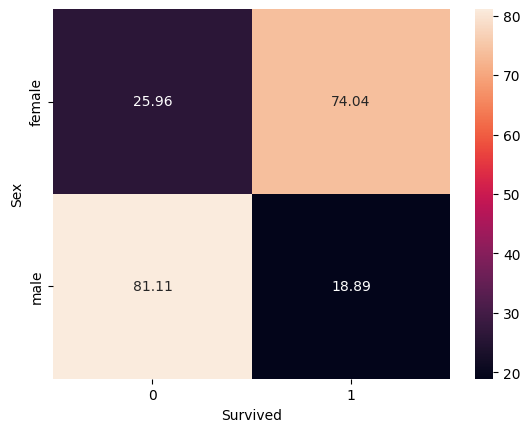

In [ ]:
sns.heatmap(cross,annot=True, fmt='.2f')

#### Survived vs Embarked
- More people survived which are from cherbourg (percentage-wise).
- By percentage, survival rate is close for people from queenstown and Southampton.

In [ ]:
pd.crosstab(titanic["Embarked"],titanic["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [ ]:
cross = pd.crosstab(titanic["Embarked"],titanic["Survived"],normalize="index")*100
cross

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


<Axes: xlabel='Survived', ylabel='Embarked'>

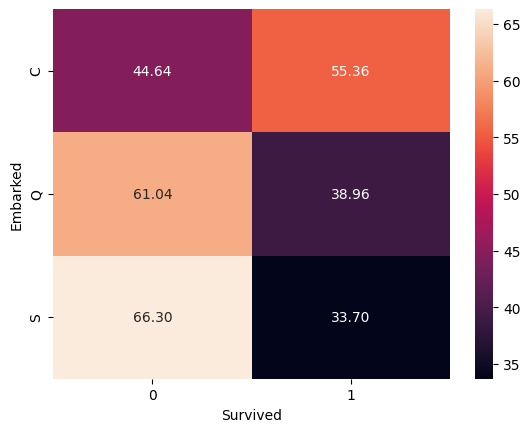

In [ ]:
sns.heatmap(cross,annot=True, fmt='.2f')

#### Survived vs Sex
- In males, people who survived were on a youger side, where as it is opposite in females.

<Axes: xlabel='Survived', ylabel='Age'>

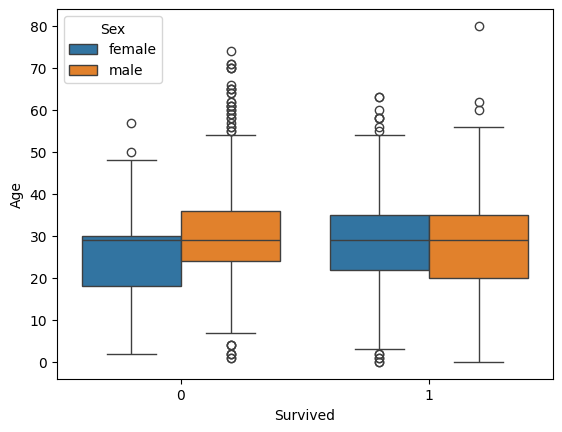

In [ ]:
sns.boxplot(x="Survived", y="Age", data=titanic, hue="Sex")

In [ ]:
titanic.groupby(["Survived","Sex"])["Age"].mean().unstack()

/tmp/ipython-input-294/2458851077.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(["Survived","Sex"])["Age"].mean().unstack()


Sex,female,male
Survived,,
0,25.864198,30.997863
1,28.679654,27.495413


#### Survived vs Fare
- people who paid more have a higher chances of survival.

<Axes: xlabel='Survived', ylabel='Individual_fare'>

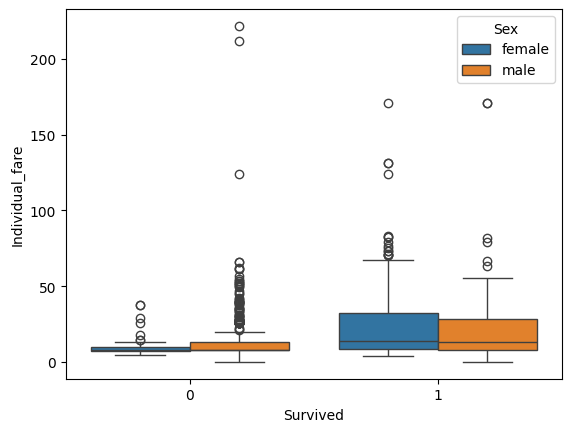

In [ ]:
sns.boxplot(x="Survived", y="Individual_fare", data=titanic, hue="Sex")

In [ ]:
titanic.groupby(["Survived","Sex"])["Individual_fare"].mean().unstack()

/tmp/ipython-input-294/2610678312.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(["Survived","Sex"])["Individual_fare"].mean().unstack()


Sex,female,male
Survived,,
0,9.294968,14.255795
1,25.608370,22.292213


#### Survived vs Is_alone
- People with families have higher percentage of surviving.

In [ ]:
pd.crosstab(titanic["Is_alone"],titanic["Survived"])

Survived,0,1
Is_alone,,
0,175,179
1,374,161


In [ ]:
cross = pd.crosstab(titanic["Is_alone"],titanic["Survived"],normalize="index")*100
cross

Survived,0,1
Is_alone,,
0,49.435028,50.564972
1,69.906542,30.093458


<Axes: xlabel='Survived', ylabel='Is_alone'>

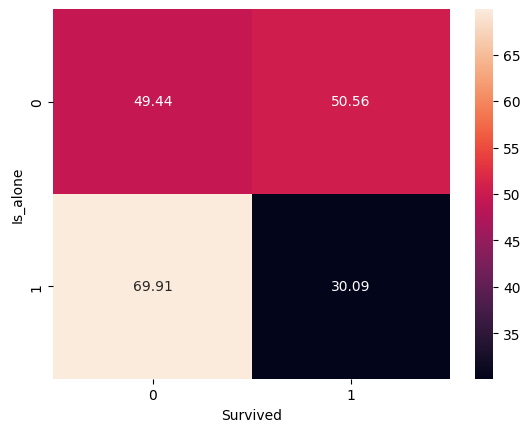

In [ ]:
sns.heatmap(cross,annot=True, fmt='.2f')

**Correlation between Columns**

<Axes: >

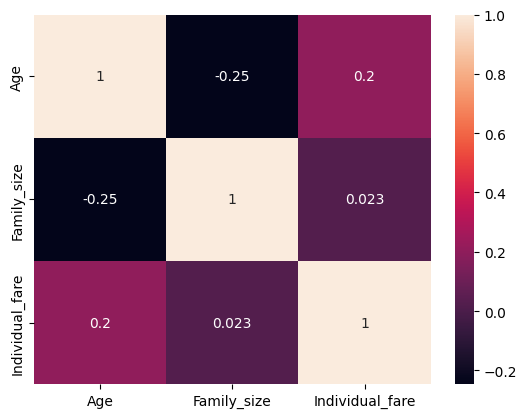

In [ ]:
sns.heatmap(titanic[["Age","Family_size","Individual_fare"]].corr(),annot=True)

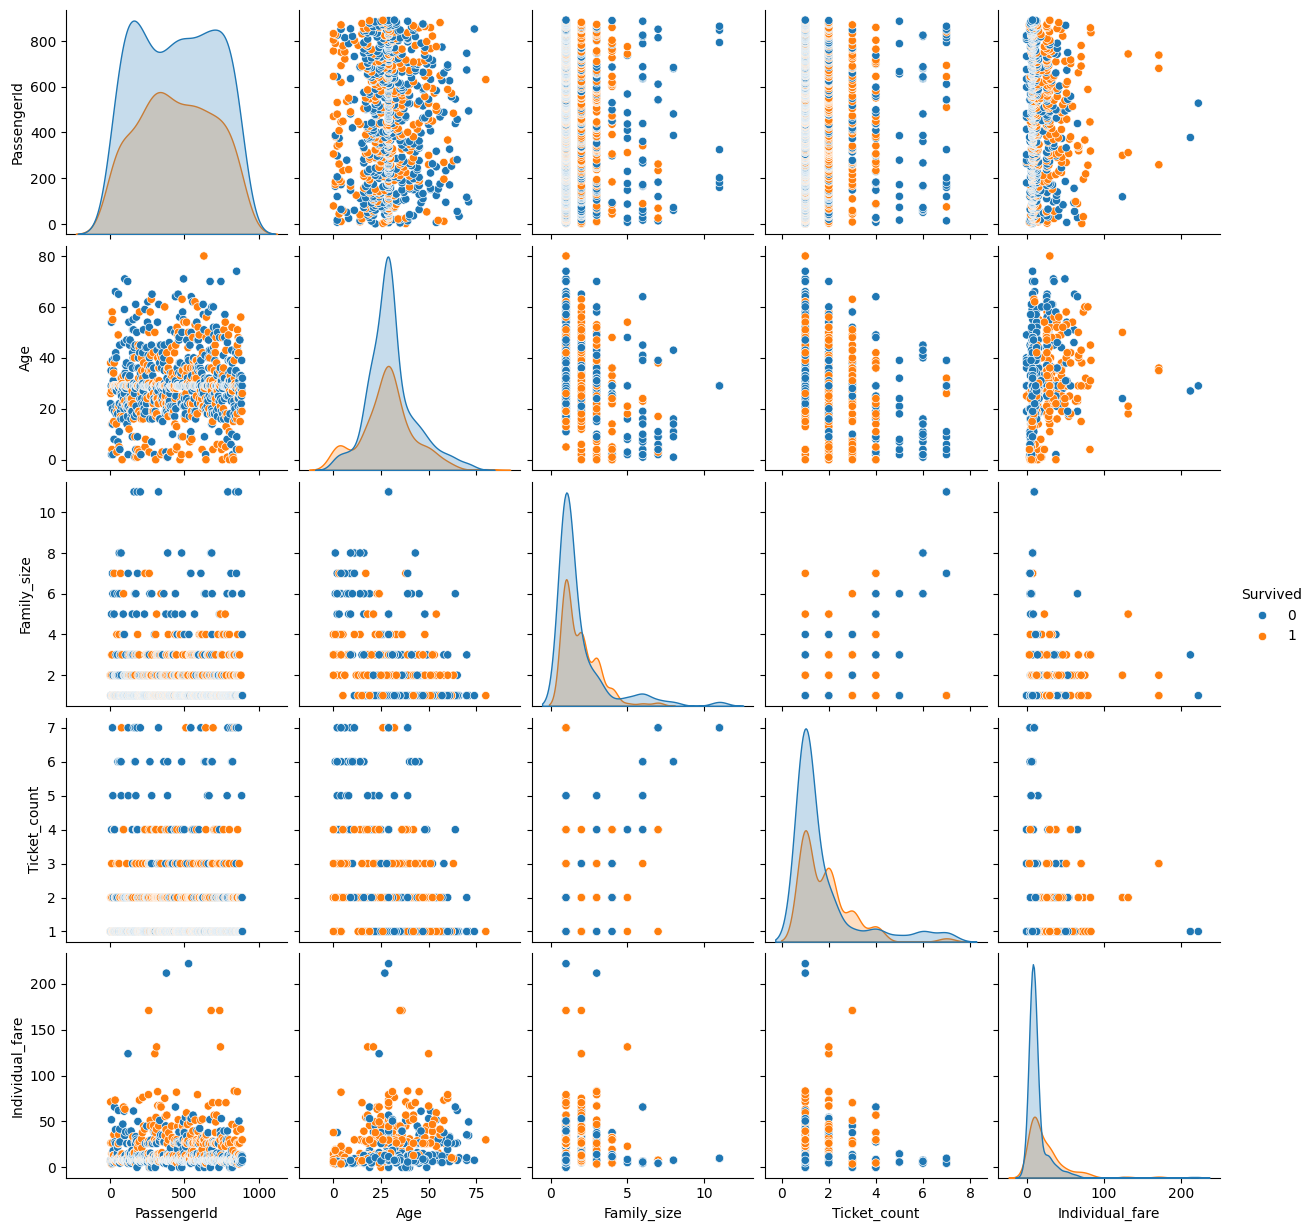

In [ ]:
sns.pairplot(titanic, hue="Survived")

# 🏁 Conclusion

In this exploratory data analysis, we examined the key features of the dataset to understand patterns influencing passenger survival.

The analysis revealed that survival was strongly associated with factors such as passenger class, gender, and fare. Females and passengers in higher classes showed significantly higher survival rates. Age also showed variation in survival probability, although its impact was less dominant compared to class and gender.

Categorical and numerical features were analyzed through univariate, bivariate, and multivariate approaches to uncover relationships and interactions between variables. Missing values and data structure were carefully reviewed to ensure proper understanding before modeling.

Overall, the dataset demonstrates clear patterns that can be leveraged in predictive modeling. The insights gained from this EDA provide a solid foundation for feature engineering and building machine learning models to predict survival outcomes effectively.